<h1 style="text_align:centre">Credit Risk Prediction</h1>

In [1]:
#importing the libraries
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
pd.set_option('display.float_format', lambda x: '%.2f' % x)

### Step 1 - Data Import

Three datasets are at our disposal:
1. Customers Dataset: This dataset includes home, work, and personal information about the borrowers. Each customer has a distinct customer ID.
2. Bureau Dataset: This dataset includes consumer credit information that was gathered from the Credit Bureau.
3. Loan Dataset: This dataset includes the clients' loan information. Additionally, the information includes a target field named "default" that indicates if the borrower has failed to make loan payments.

In [2]:
#importing the 3 datasets
df_bureau = pd.read_csv("Datasets/bureau_data.csv")
df_bureau.head()

,cust_id,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,1,1,42,0,0,3,7
1,C00002,3,1,96,12,60,5,4
2,C00003,2,1,82,24,147,6,58
3,C00004,3,0,115,15,87,5,26
4,C00005,4,2,120,0,0,5,10


In [3]:
df_cust = pd.read_csv("Datasets/customers.csv")
df_cust.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,Delhi,110001
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,Tamil Nadu,600001
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,West Bengal,700001
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,Karnataka,560001
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,Maharashtra,411001


In [4]:
df_loans = pd.read_csv("Datasets/loans.csv")
df_loans.head()

,loan_id,cust_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,L00001,C00001,Auto,Secured,3004000,2467000,49340.00,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,L00002,C00002,Home,Secured,4161000,3883000,77660.00,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,L00003,C00003,Personal,Unsecured,2401000,2170000,43400.00,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False
3,L00004,C00004,Personal,Unsecured,2345000,1747000,34940.00,314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,False
4,L00005,C00005,Auto,Secured,4647000,4520000,90400.00,813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,False


In [5]:
# Merging all the datasets into one pandas dataframe
df = pd.merge(df_cust,df_loans,on="cust_id")
df = pd.merge(df,df_bureau,on="cust_id")
df.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2019-07-24,2019-08-10,False,1,1,42,0,0,3,7
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,2019-07-24,2019-08-15,False,3,1,96,12,60,5,4
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2019-07-24,2019-08-21,False,2,1,82,24,147,6,58
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,...,2019-07-24,2019-08-09,False,3,0,115,15,87,5,26
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,...,2019-07-24,2019-08-02,False,4,2,120,0,0,5,10


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cust_id                      50000 non-null  object 
 1   age                          50000 non-null  int64  
 2   gender                       50000 non-null  object 
 3   marital_status               50000 non-null  object 
 4   employment_status            50000 non-null  object 
 5   income                       50000 non-null  int64  
 6   number_of_dependants         50000 non-null  int64  
 7   residence_type               49938 non-null  object 
 8   years_at_current_address     50000 non-null  int64  
 9   city                         50000 non-null  object 
 10  state                        50000 non-null  object 
 11  zipcode                      50000 non-null  int64  
 12  loan_id                      50000 non-null  object 
 13  loan_purpose    

In [7]:
df["default"] = df["default"].astype(int)
df["default"].value_counts()

default
0    45703
1     4297
Name: count, dtype: int64

The target class suffers from class imbalance. We will address this issue later.

### Step 2 - Train Test Split

We will divide the dataset into Train Data Set and Test Data Set in order to prevent the issue of data leakage.

In [8]:
from sklearn.model_selection import train_test_split
X = df.drop(columns="default")
y = df["default"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42)

df_train = pd.concat([X_train,y_train],axis=1)
df_test = pd.concat([X_test,y_test],axis=1)

In [9]:
df_train.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default
27434,C27435,45,F,Single,Salaried,1131000,0,Owned,5,Ahmedabad,...,2022-04-21,2022-05-21,4,2,90,6,33,8,59,0
13400,C13401,29,M,Single,Salaried,2343000,0,Owned,25,Delhi,...,2020-11-24,2020-12-11,3,1,119,4,17,4,92,0
883,C00884,50,F,Single,Self-Employed,2891000,0,Mortgage,29,Lucknow,...,2019-08-25,2019-09-19,2,1,83,14,78,4,83,0
7303,C07304,43,F,Single,Self-Employed,272000,1,Owned,27,Bangalore,...,2020-04-16,2020-05-05,1,1,37,0,0,5,34,0
45124,C45125,31,F,Single,Salaried,141000,0,Owned,27,Jaipur,...,2024-01-26,2024-02-17,2,0,62,6,28,5,19,0


In [10]:
df_train.shape, df_test.shape #printing the size of the train set and test set

((37500, 33), (12500, 33))

### Step 3 - Data Cleaning

In [11]:
#checking for null entries
df_train.isna().sum()

cust_id                         0
age                             0
gender                          0
marital_status                  0
employment_status               0
income                          0
number_of_dependants            0
residence_type                 48
years_at_current_address        0
city                            0
state                           0
zipcode                         0
loan_id                         0
loan_purpose                    0
loan_type                       0
sanction_amount                 0
loan_amount                     0
processing_fee                  0
gst                             0
net_disbursement                0
loan_tenure_months              0
principal_outstanding           0
bank_balance_at_application     0
disbursal_date                  0
installment_start_dt            0
number_of_open_accounts         0
number_of_closed_accounts       0
total_loan_months               0
delinquent_months               0
total_dpd     

We have 48 null values in the residence_type column

In [12]:
df_train["residence_type"].unique()

array(['Owned', 'Mortgage', 'Rented', nan], dtype=object)

In [13]:
#replacing with mode value of residence_type in train and test sets
mode_val = df_train["residence_type"].mode()[0]
mode_val

'Owned'

In [14]:
df_train.fillna({"residence_type":mode_val},inplace=True)

In [15]:
mode_val = df_test["residence_type"].mode()[0]
df_test.fillna({"residence_type":mode_val},inplace=True)

In [16]:
#checking for duplicates
df_train.duplicated().sum()

np.int64(0)

In [17]:
df_test.duplicated().sum()

np.int64(0)

There are 0 duplicates in the train and test set

In [18]:
#checking for outliers

numerical_cols = ["age","income","number_of_dependants","years_at_current_address","sanction_amount","loan_amount",
                 "processing_fee","gst","net_disbursement","loan_tenure_months","principal_outstanding",
                 "bank_balance_at_application","number_of_open_accounts","number_of_closed_accounts","total_loan_months",
                 "delinquent_months","total_dpd","enquiry_count","credit_utilization_ratio"]
categorical_cols = ["gender","marital_status","employment_status","residence_type","city","state","zipcode",
                   "loan_purpose","loan_type","default"]

To view the data distribution in the numerical columns and look for outliers, we will draw box plots and histograms.

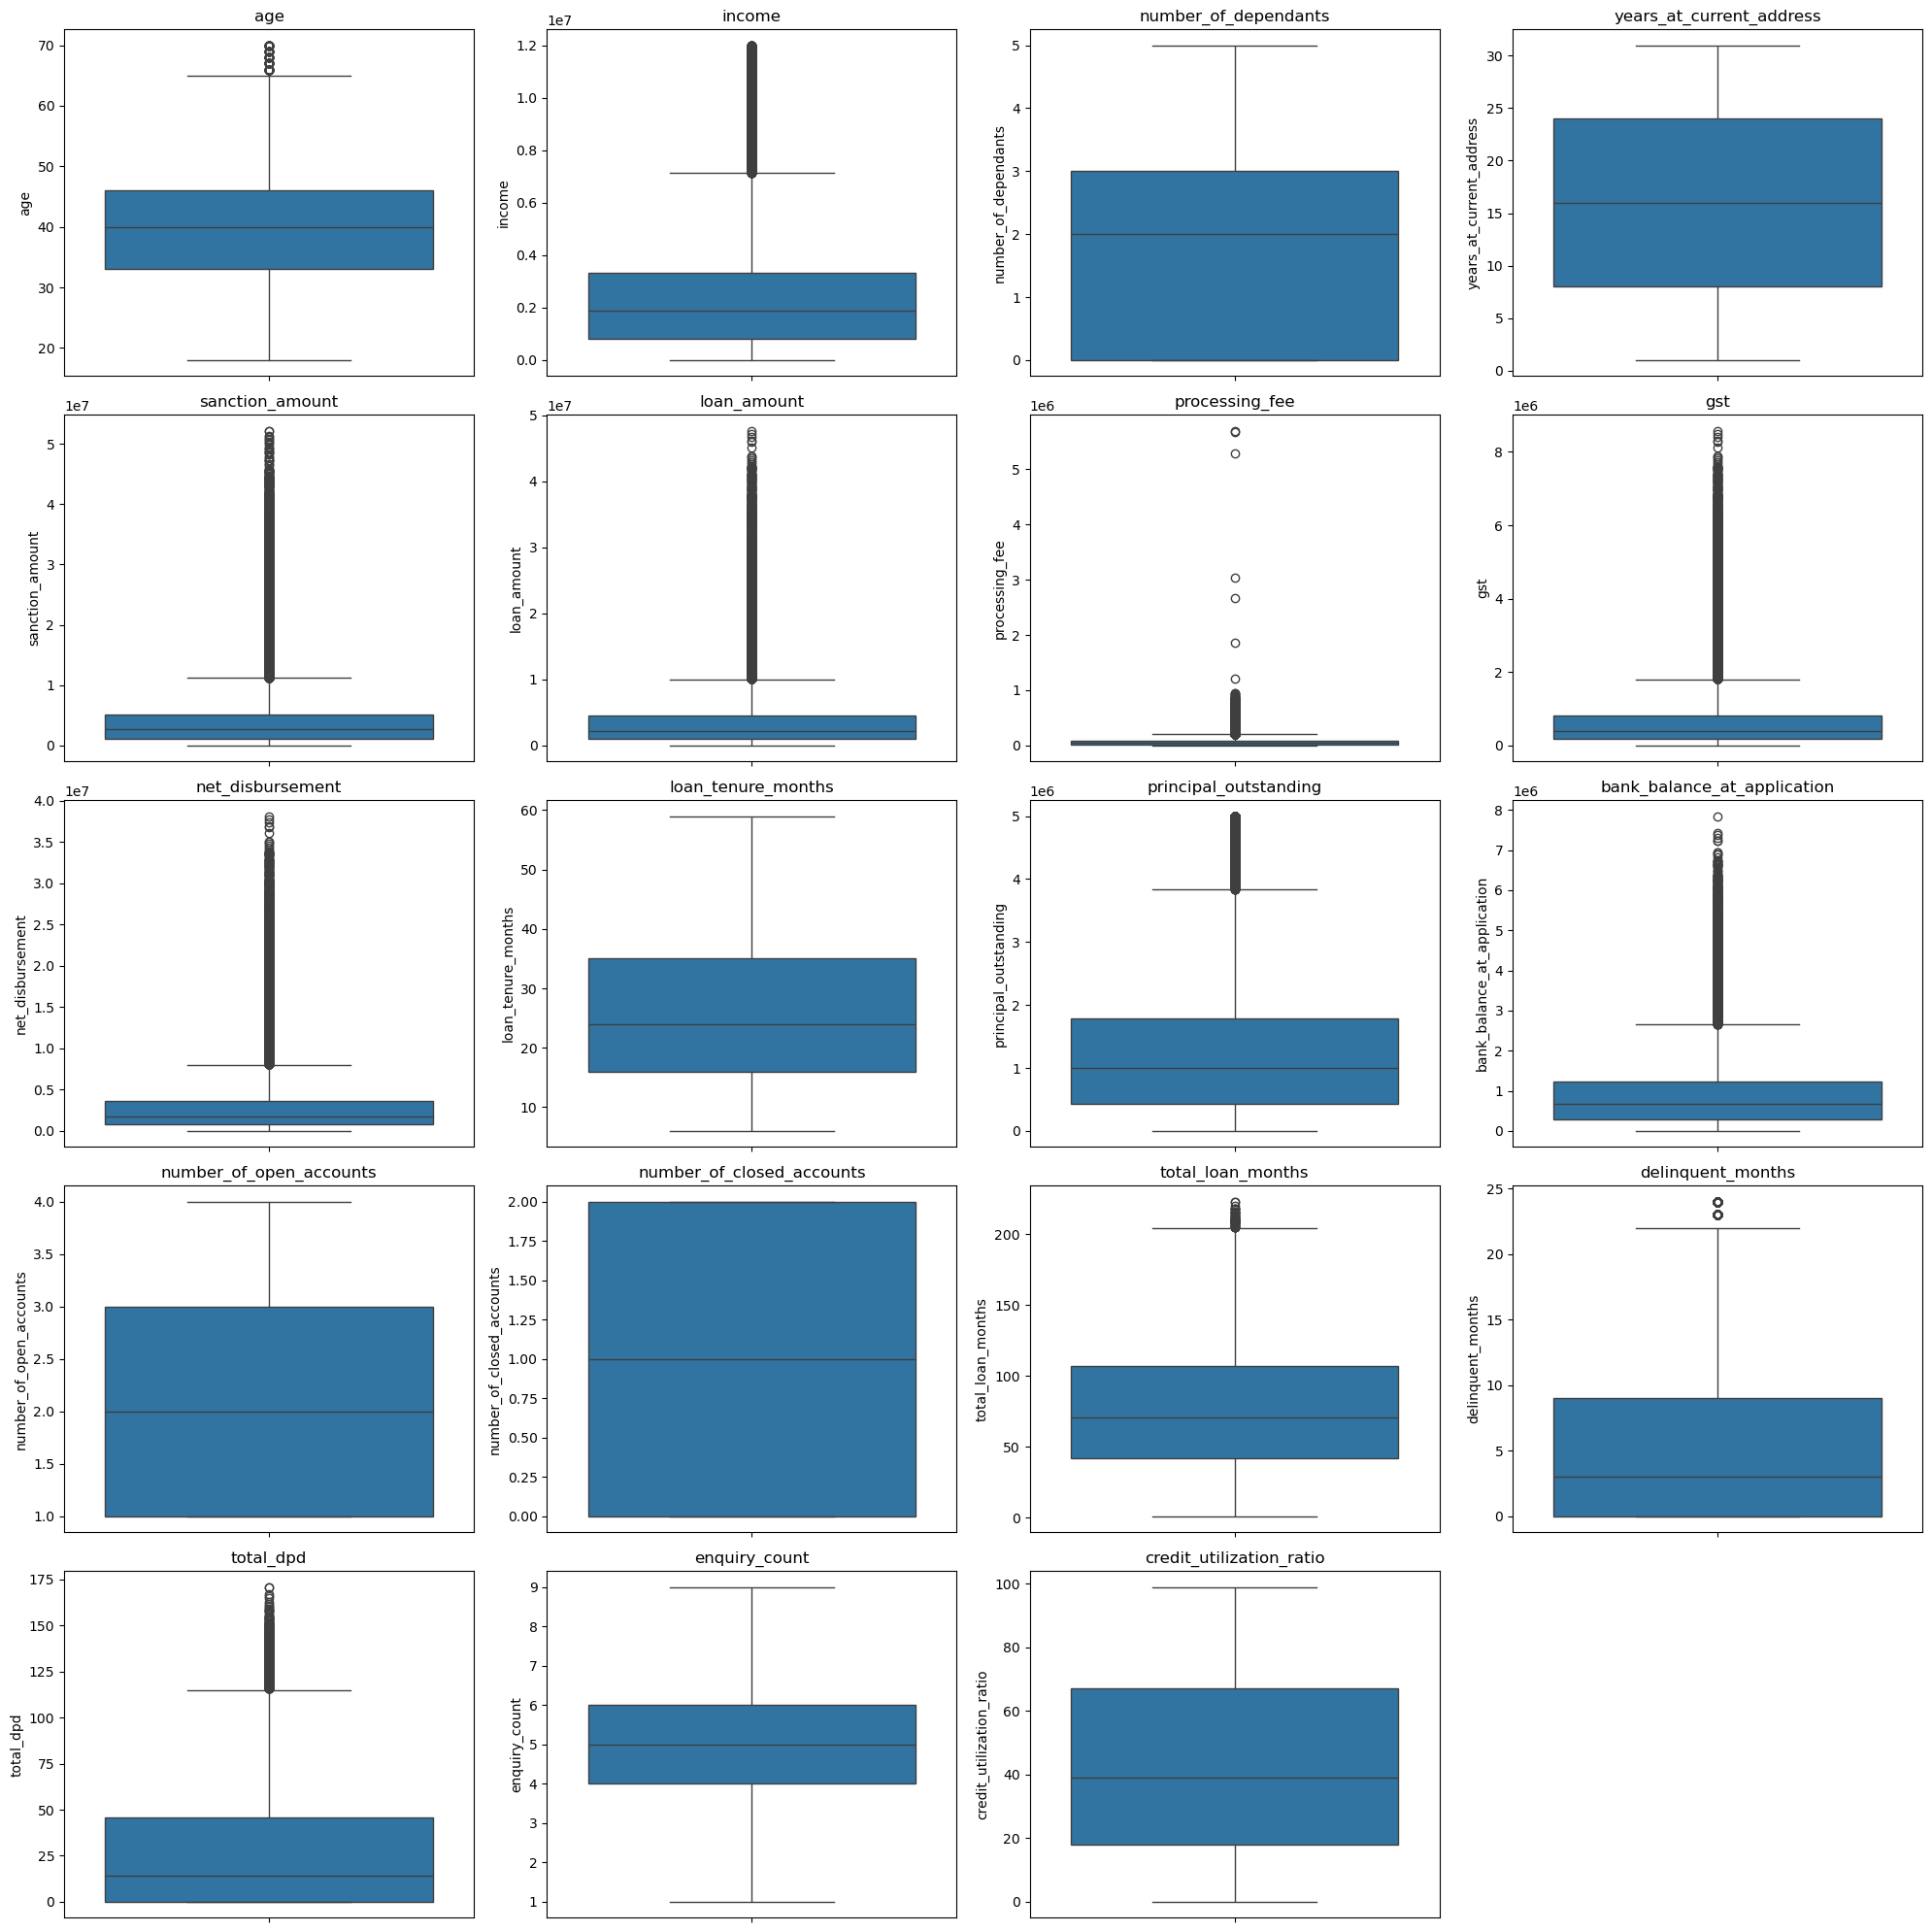

In [19]:
import math

n_cols = 4
n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df_train[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')

# Remove empty subplots
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

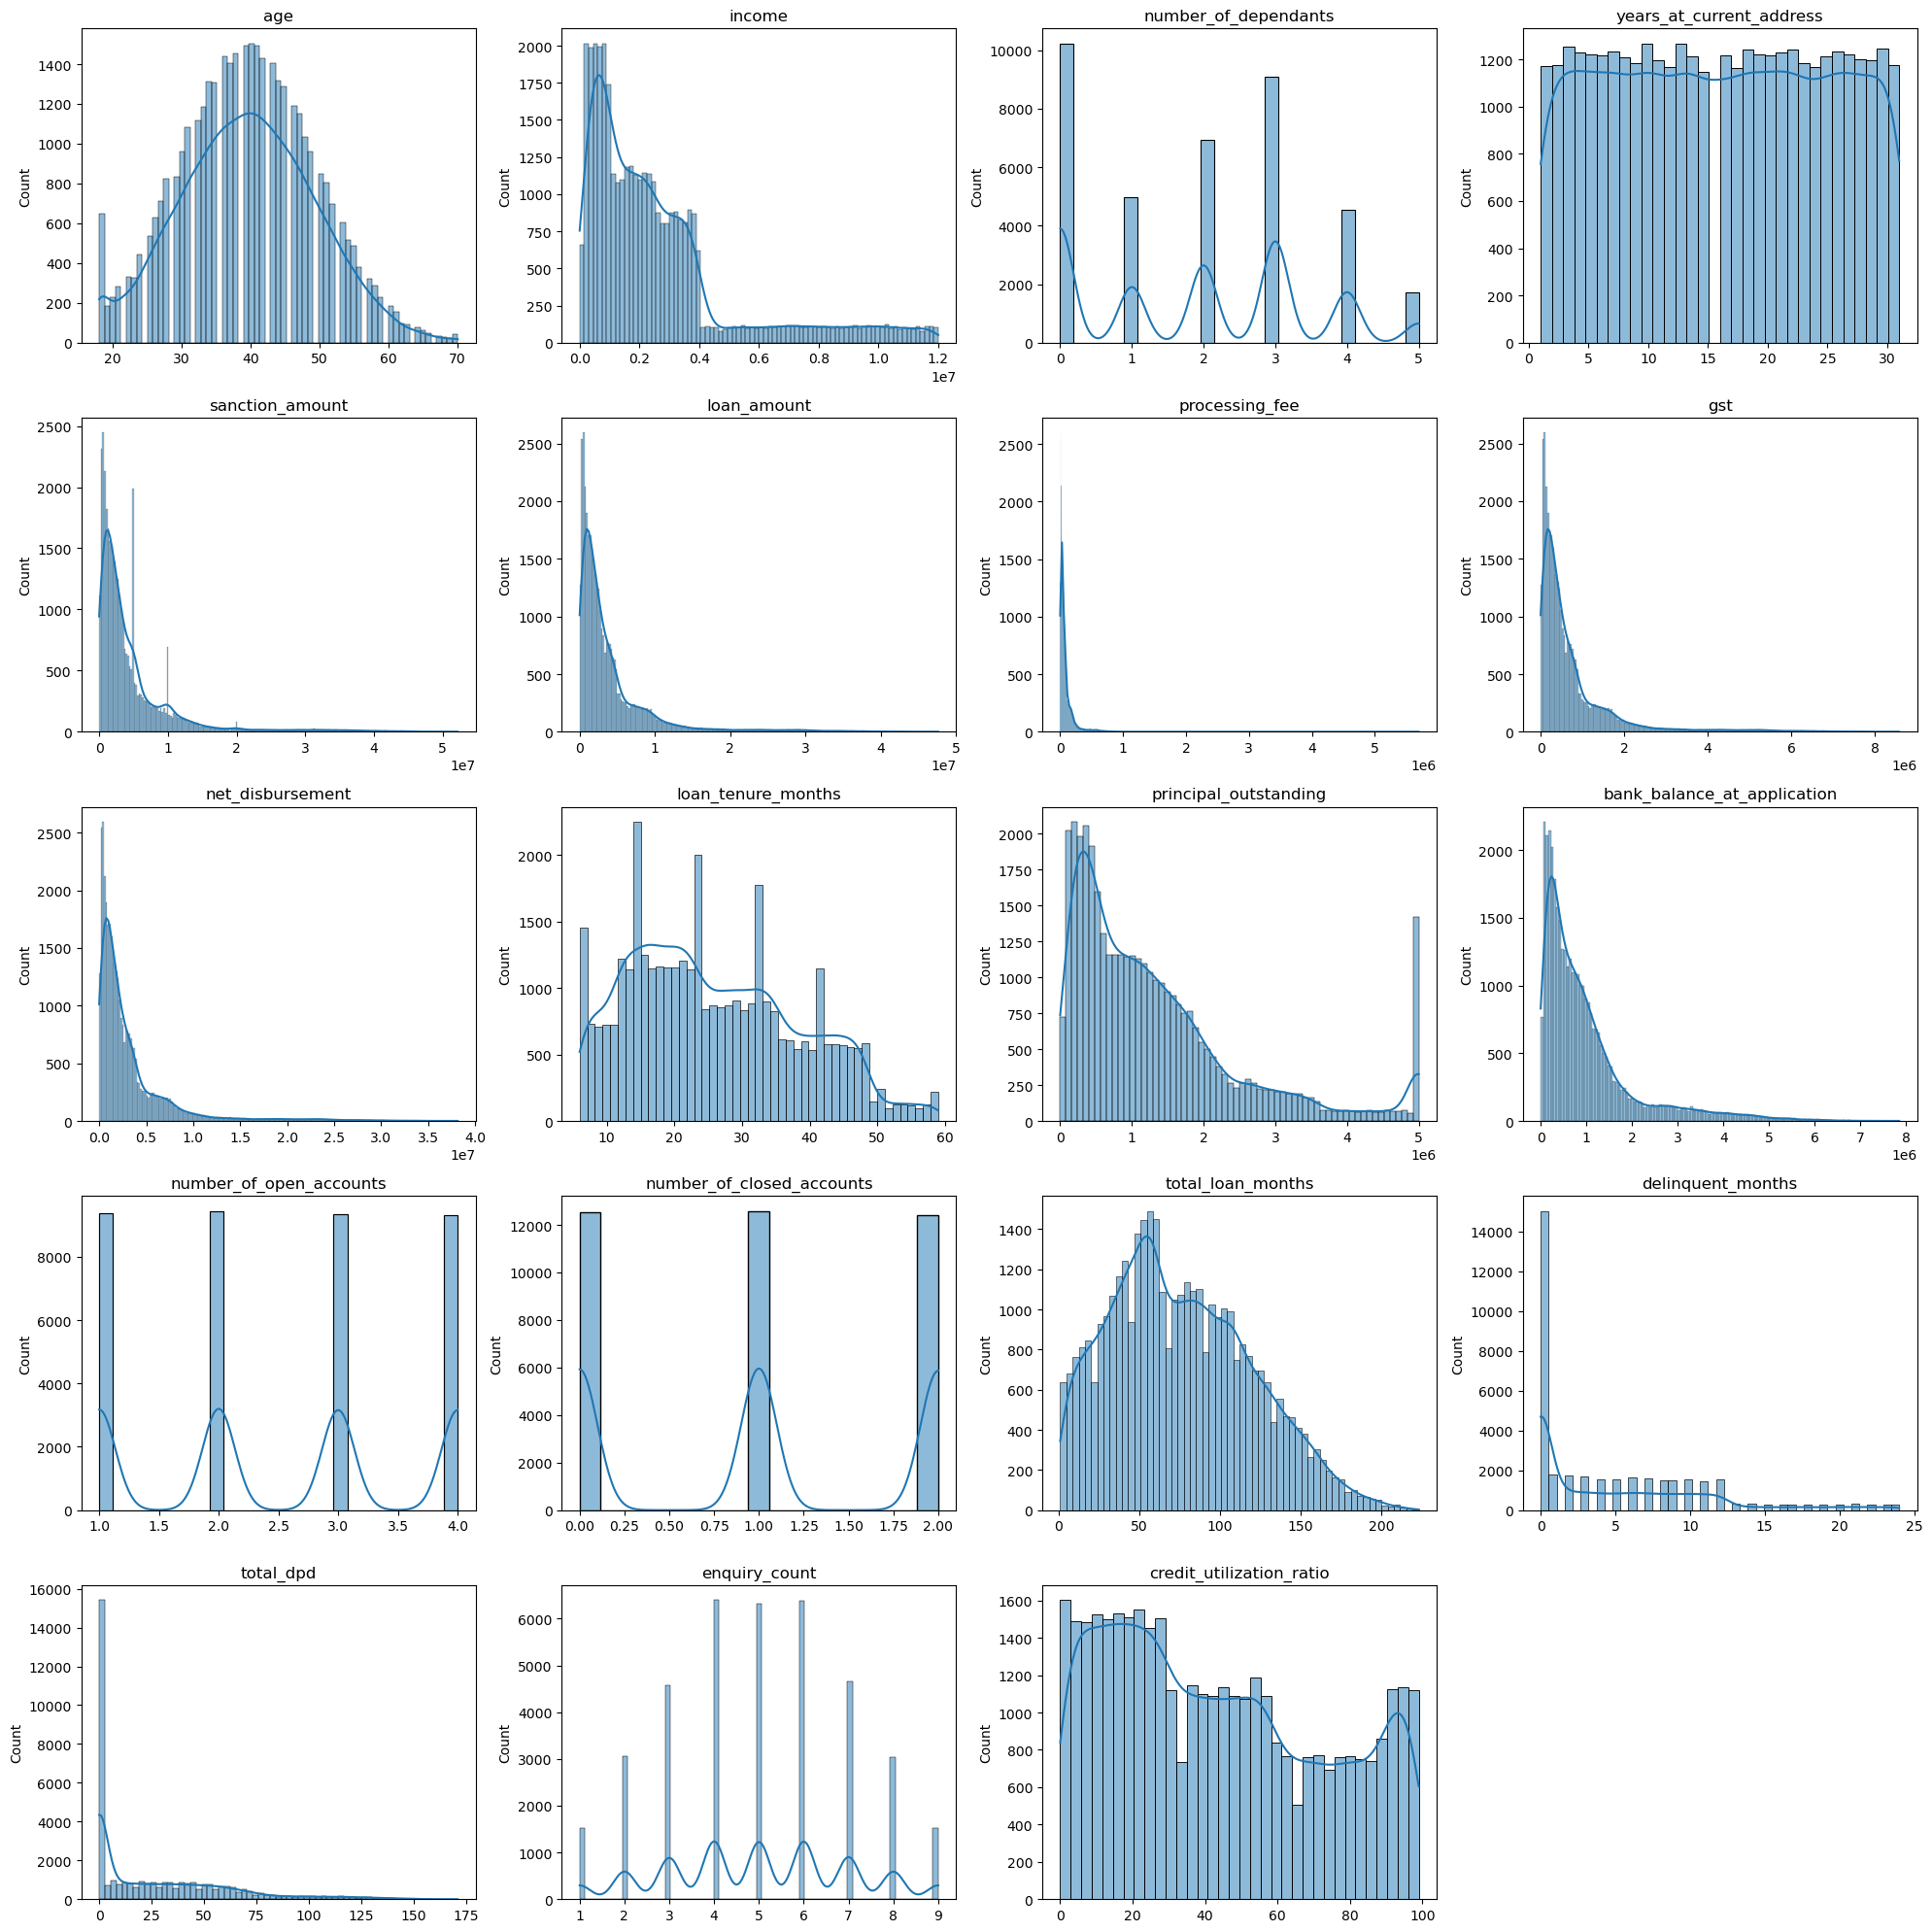

In [20]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(x=df_train[col], kde = True, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')

# Remove empty subplots
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

1) The processing_fee and gst columns appear to contain a few outliers.
2) We shall examine these columns in more detail.

In [21]:
df_train["processing_fee"].describe()

count     37500.00
mean      80724.11
std      120830.65
min           0.00
25%       19180.00
50%       44700.00
75%       92000.00
max     5698029.90
Name: processing_fee, dtype: float64

The processing fee column appears to have a few outliers.

In [22]:
#Finding the records having processing fee greater than 3% of the loan amount
df_train[(df_train["processing_fee"]/df_train["loan_amount"])>0.03][["loan_amount","processing_fee"]]

,loan_amount,processing_fee
23981,2234000,2669791.02
9898,3626000,5293543.52
47089,1738000,1858964.77
33705,3812000,5678020.86
12294,4639000,5698029.90
28174,966000,1214492.67
29305,2616000,3036378.01


In [23]:
#dropping the above cols
df_train_1 = df_train[(df_train["processing_fee"]/df_train["loan_amount"])<=0.03].copy()

In [24]:
#making the same transformation in the test set
df_test = df_test[(df_test["processing_fee"]/df_test["loan_amount"])<=0.03].copy()

In [25]:
#analysing the gst column. Finding the rows having gst > 20% of the loan amount
df_train_1[(df_train_1["gst"]/df_train_1["loan_amount"])>0.20][["loan_amount","gst"]]

,loan_amount,gst


In [26]:
#analysing the net_disbursement column. Finding the rows having net_disbursement > loan amount
df_train_1[df_train_1["net_disbursement"]>df_train_1["loan_amount"]][["loan_amount","net_disbursement"]]

,loan_amount,net_disbursement


In [27]:
#analysing the net_disbursement column. Finding the rows having net_disbursement <> loan amount - (processing_fee + gst)
df_train_1[df_train_1["net_disbursement"] != (df_train_1["loan_amount"] - (df_train_1["processing_fee"] + df_train_1["gst"]))]

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default


The data and the outliers in the numerical columns have been cleaned and handled. Now let's examine the category columns.

In [28]:
for col in categorical_cols:
    print(f"{col} ----> {df_train[col].unique()}")

gender ----> ['F' 'M']
marital_status ----> ['Single' 'Married']
employment_status ----> ['Salaried' 'Self-Employed']
residence_type ----> ['Owned' 'Mortgage' 'Rented']
city ----> ['Ahmedabad' 'Delhi' 'Lucknow' 'Bangalore' 'Jaipur' 'Hyderabad' 'Kolkata'
 'Pune' 'Chennai' 'Mumbai']
state ----> ['Gujarat' 'Delhi' 'Uttar Pradesh' 'Karnataka' 'Rajasthan' 'Telangana'
 'West Bengal' 'Maharashtra' 'Tamil Nadu']
zipcode ----> [380001 110001 226001 560001 302001 500001 700001 411001 600001 400001]
loan_purpose ----> ['Home' 'Auto' 'Personal' 'Education' 'Personaal']
loan_type ----> ['Secured' 'Unsecured']
default ----> [0 1]


In [29]:
#cleaning the loan_purpose column

df_train_1["loan_purpose"] = df_train_1["loan_purpose"].replace("Personaal","Personal")

In [30]:
df_test["loan_purpose"] = df_test["loan_purpose"].replace("Personaal","Personal")

In [31]:
print(df_train_1["loan_purpose"].unique())
print(df_test["loan_purpose"].unique())

['Home' 'Auto' 'Personal' 'Education']
['Education' 'Home' 'Auto' 'Personal']


### Step 4 - EDA

To gain useful insights and comprehensibility, we shall investigate the data further. 

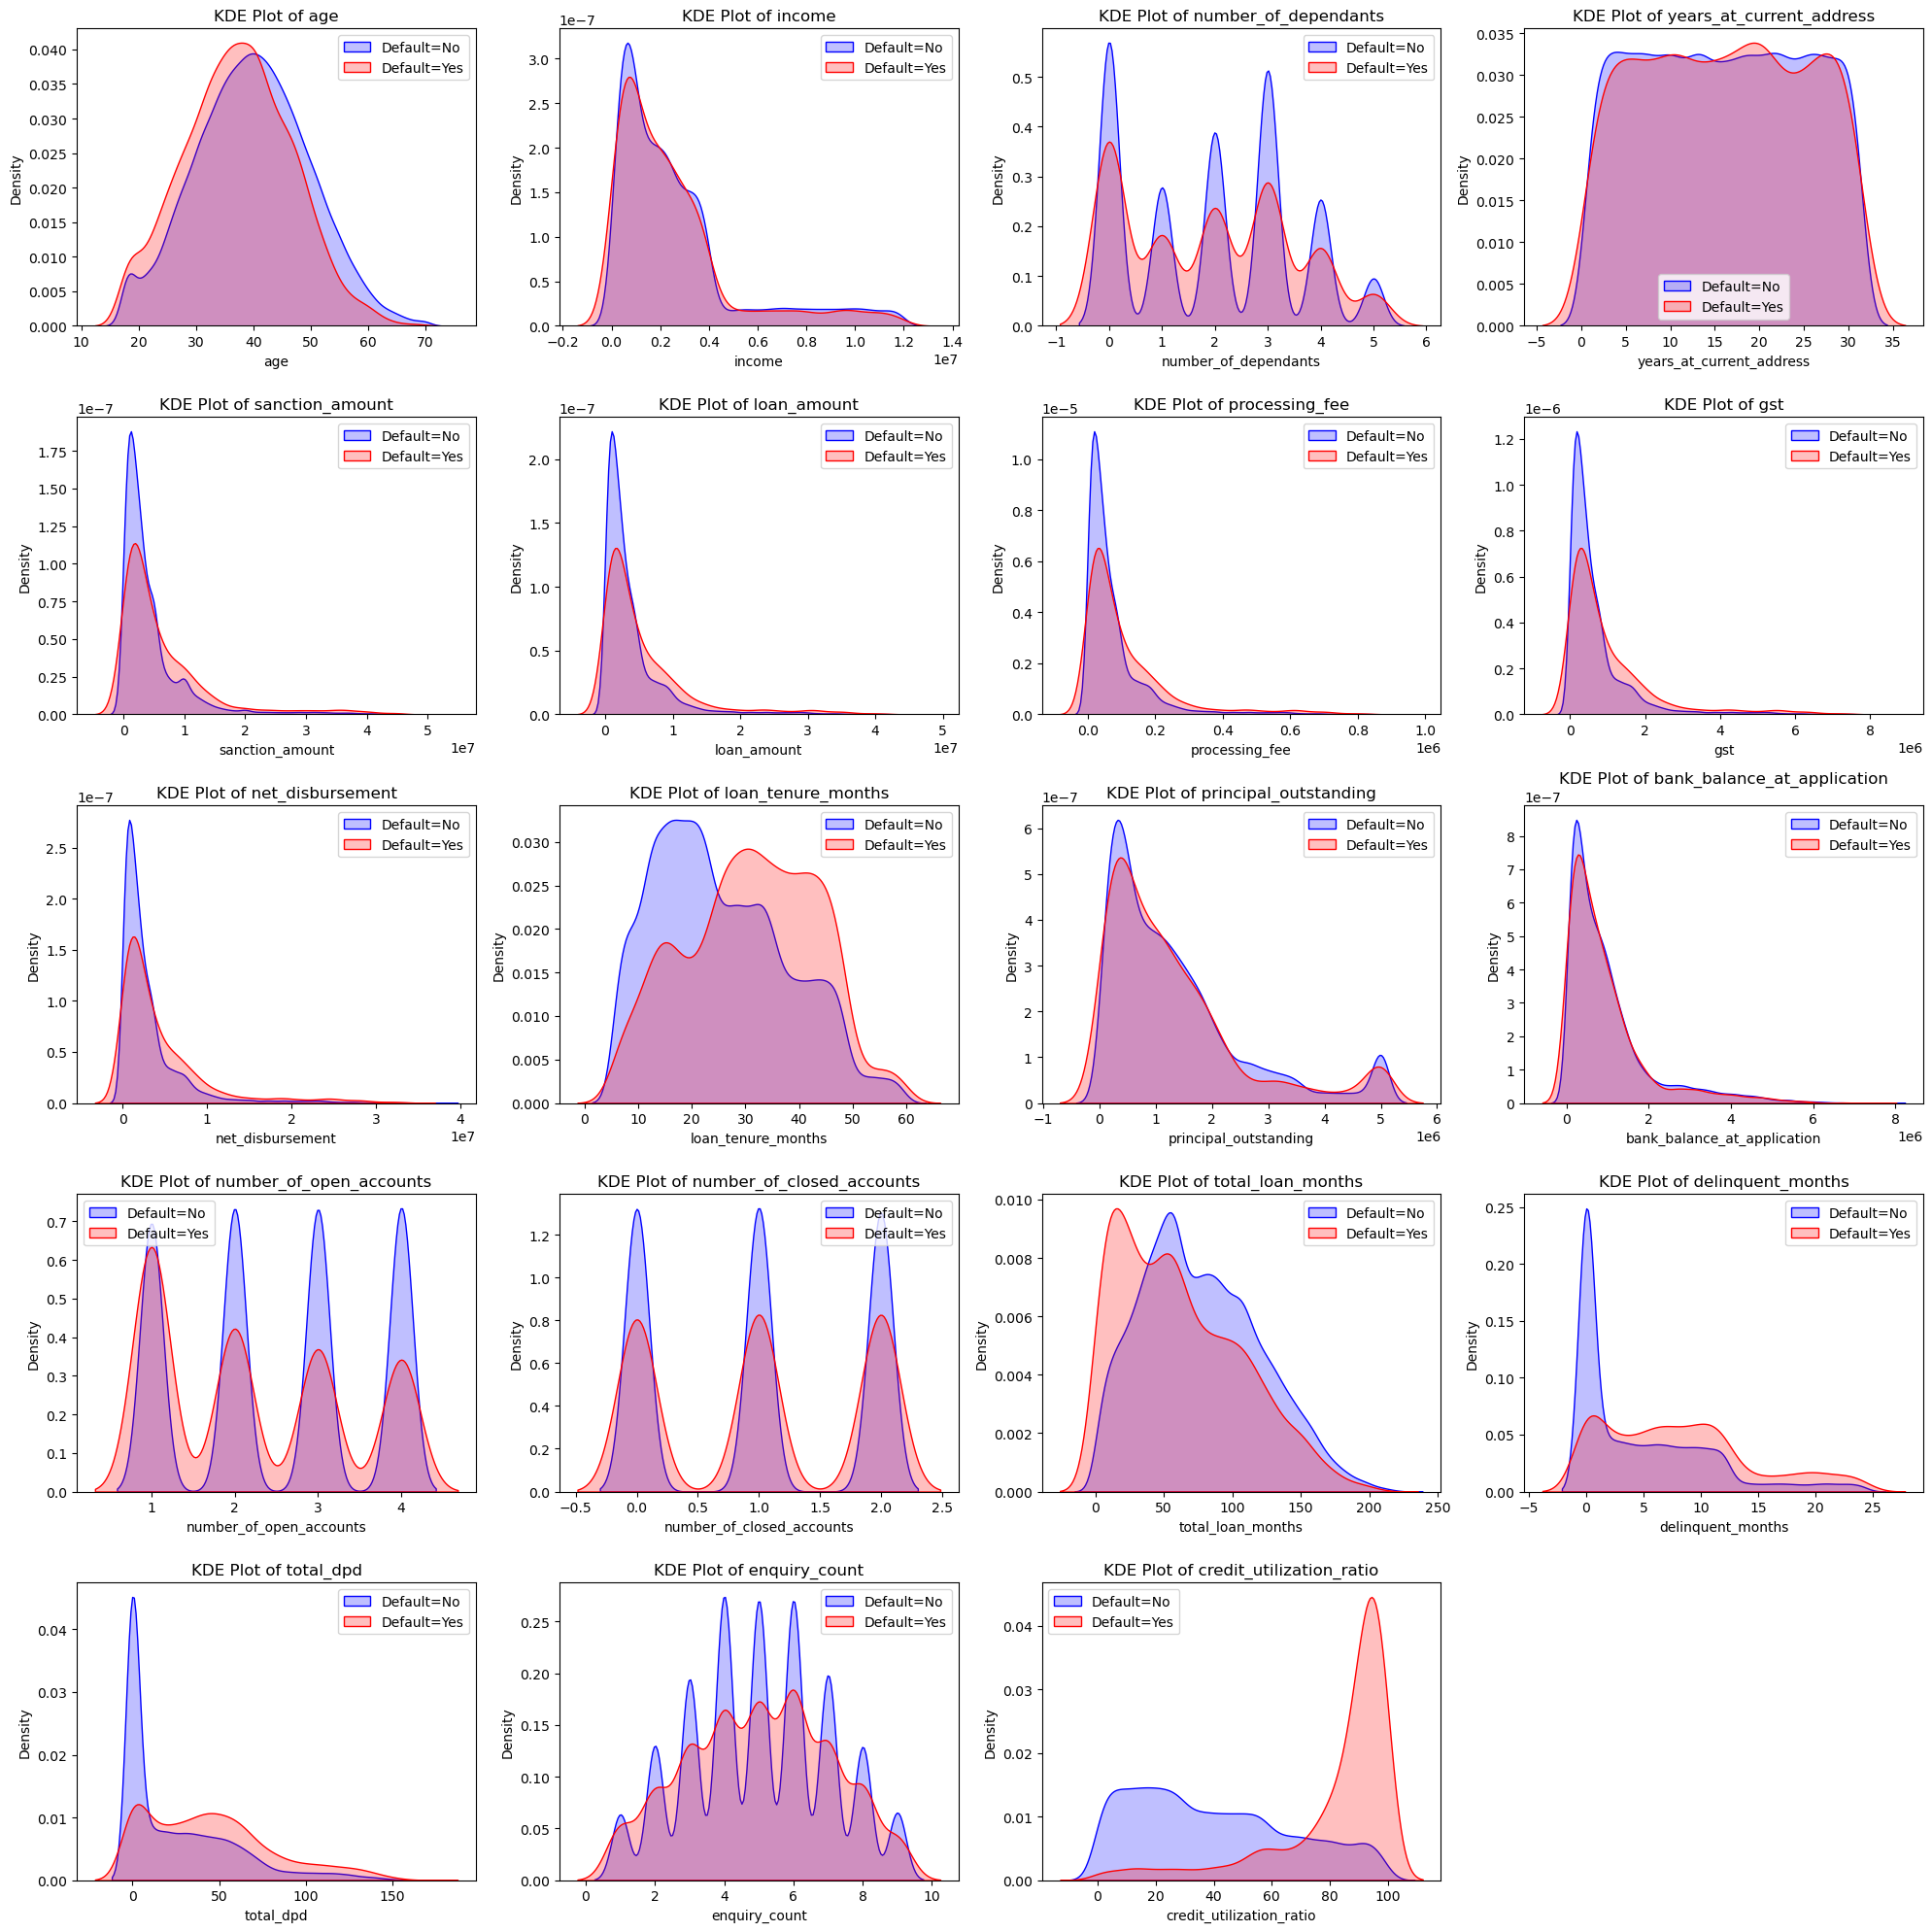

In [32]:
#printing KDE plots

n_cols = 4
n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.kdeplot(df_train_1[df_train_1.default == 0][col], color="blue", fill=True, label="Default=No", ax=axes[i])
    sns.kdeplot(df_train_1[df_train_1.default == 1][col], color="red", fill=True, label="Default=Yes", ax=axes[i])
    axes[i].set_title(f"KDE Plot of {col}")
    axes[i].legend()

# Remove empty subplots
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

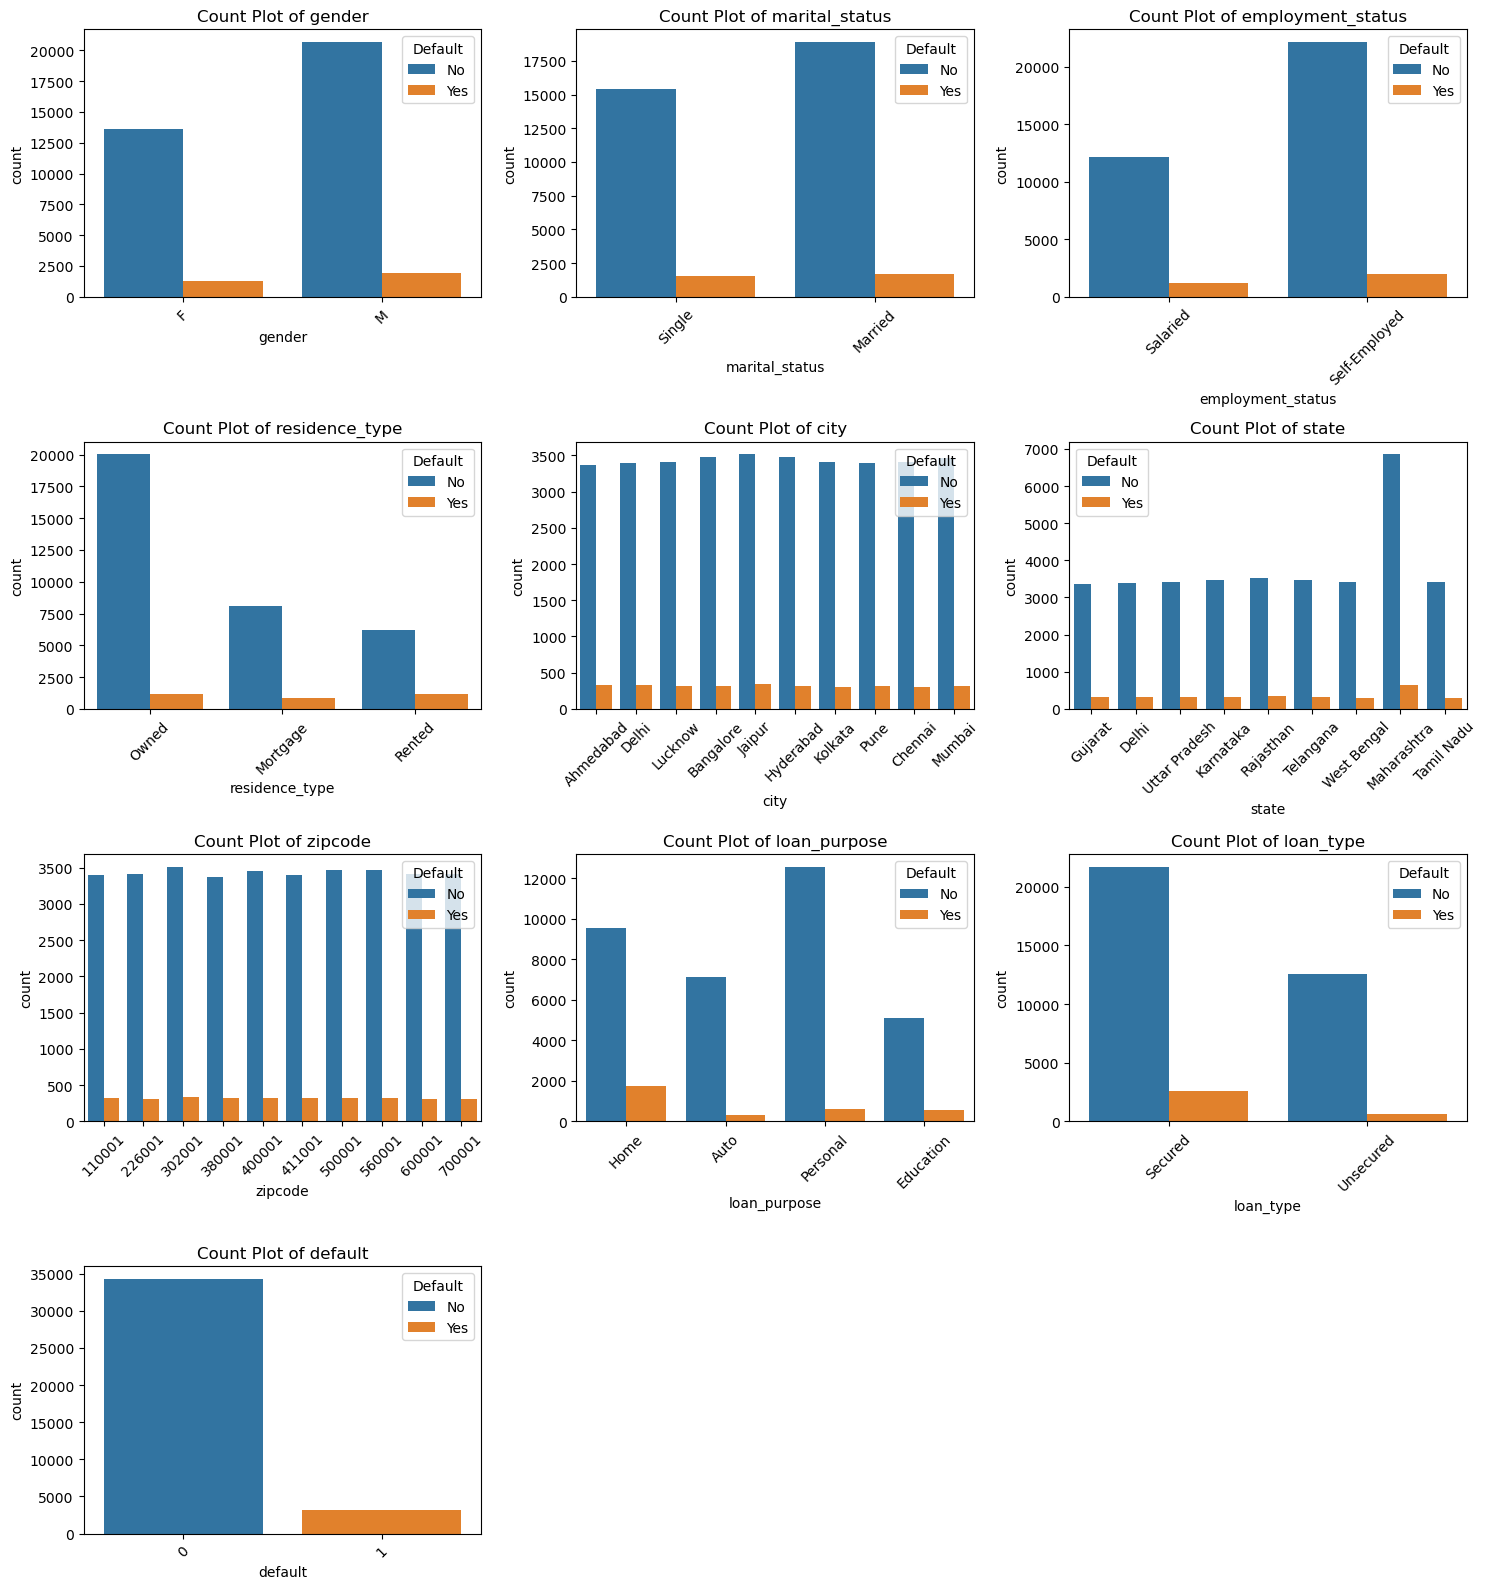

In [33]:
n_cols = 3
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df_train_1, x=col, hue="default", ax=axes[i])
    axes[i].set_title(f"Count Plot of {col}")
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title="Default", labels=["No", "Yes"])

# Remove empty subplots
for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Insights

The likelihood of following clients defaulting is higher.

1) Individuals in the younger age group
2) Individuals with longer loan terms
3) Individuals with more open accounts
4) Individuals with a high number of months of delinquency
5) Individuals with elevated DPD
6) Individuals with a high credit use ratio
7) Individuals with shorter loan terms
8) People who don't own a home

### Step 5 - Feature Engineering

From the current features, we will create additional ones that will increase the predictive ability of our model.

In [34]:
#creating a new column - loan_to_income_ratio
df_train_1["loan_to_income_ratio"] = round(df_train_1["loan_amount"]/df_train_1["income"],2)
df_test["loan_to_income_ratio"] = round(df_test["loan_amount"]/df_test["income"],2)

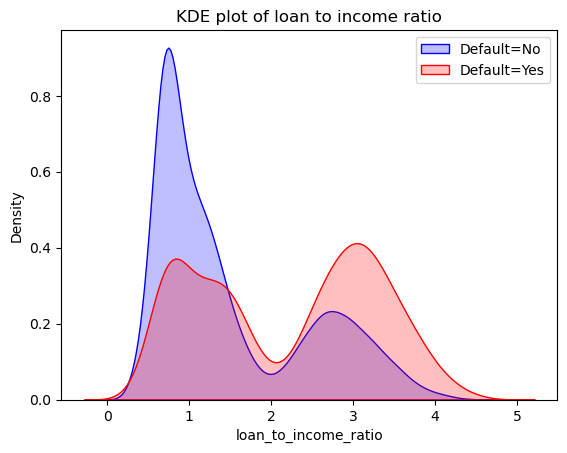

In [35]:
sns.kdeplot(df_train_1[df_train_1.default == 0]["loan_to_income_ratio"], color="blue", fill=True, label="Default=No")
sns.kdeplot(df_train_1[df_train_1.default == 1]["loan_to_income_ratio"], color="red", fill=True, label="Default=Yes")
plt.title("KDE plot of loan to income ratio")
plt.legend()
plt.show()

In [36]:
#creating a new column - delinquency_ratio
df_train_1["delinquency_ratio"] = df_train_1["delinquent_months"]*100/df_train_1["total_loan_months"].round(1)
df_test["delinquency_ratio"] = df_test["delinquent_months"]*100/df_test["total_loan_months"].round(1)

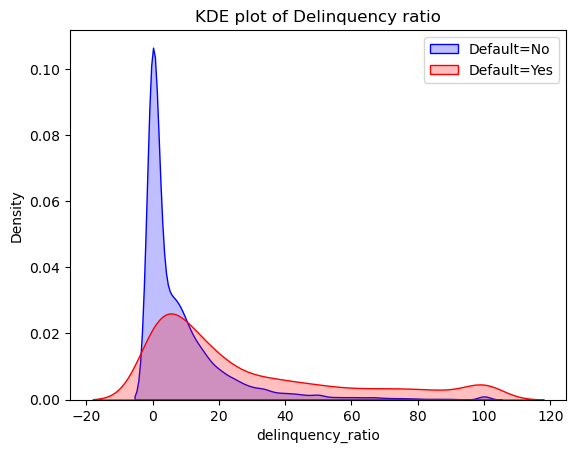

In [37]:
sns.kdeplot(df_train_1[df_train_1.default == 0]["delinquency_ratio"], color="blue", fill=True, label="Default=No")
sns.kdeplot(df_train_1[df_train_1.default == 1]["delinquency_ratio"], color="red", fill=True, label="Default=Yes")
plt.title("KDE plot of Delinquency ratio")
plt.legend()
plt.show()

In [38]:
#creating a new column - avg_dpd_per_delinquency
df_train_1["avg_dpd_per_delinquency"] = np.where(
    df_train_1["delinquent_months"]!=0,
    df_train_1["total_dpd"]/df_train_1["delinquent_months"].round(1),
    0
)
df_test["avg_dpd_per_delinquency"] = np.where(
    df_test["delinquent_months"]!=0,
    df_test["total_dpd"]/df_test["delinquent_months"].round(1),
    0
)

In [39]:
df_train_1.describe()

,age,income,number_of_dependants,years_at_current_address,zipcode,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,...,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default,loan_to_income_ratio,delinquency_ratio,avg_dpd_per_delinquency
count,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,...,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00
mean,39.56,2636119.11,1.94,15.99,418763.45,4707707.29,4003661.08,80073.22,720658.99,3202928.87,...,1.00,75.99,4.89,26.94,5.00,43.33,0.09,1.55,10.39,3.29
std,9.85,2623816.51,1.54,8.94,168837.51,6289437.60,5401552.03,108031.04,972279.36,4321241.62,...,0.82,43.71,5.86,32.93,2.02,29.36,0.28,0.97,17.27,2.90
min,18.00,100000.00,0.00,1.00,110001.00,71000.00,50000.00,1000.00,9000.00,40000.00,...,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.30,0.00,0.00
25%,33.00,803000.00,0.00,8.00,302001.00,1136000.00,959500.00,19190.00,172710.00,767600.00,...,0.00,42.00,0.00,0.00,4.00,18.00,0.00,0.77,0.00,0.00
50%,40.00,1884000.00,2.00,16.00,400001.00,2652000.00,2235000.00,44700.00,402300.00,1788000.00,...,1.00,71.00,3.00,14.00,5.00,39.00,0.00,1.16,3.80,4.33
75%,46.00,3331500.00,3.00,24.00,560001.00,5159500.00,4598000.00,91960.00,827640.00,3678400.00,...,2.00,107.00,9.00,46.00,6.00,67.00,0.00,2.45,13.11,5.75
max,70.00,11999000.00,5.00,31.00,700001.00,52175000.00,47667000.00,953340.00,8580060.00,38133600.00,...,2.00,223.00,24.00,171.00,9.00,99.00,1.00,4.57,100.00,10.00


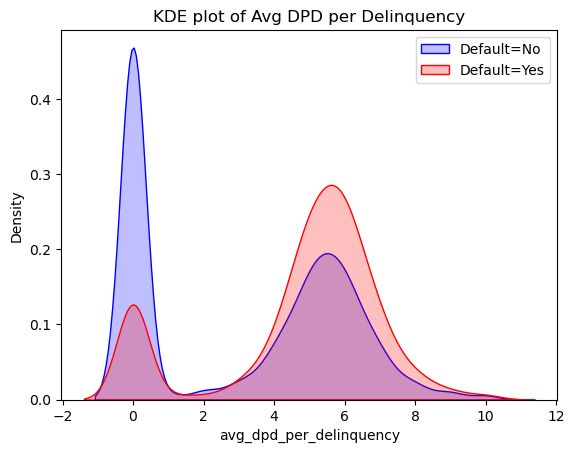

In [40]:
sns.kdeplot(df_train_1[df_train_1.default == 0]["avg_dpd_per_delinquency"], color="blue", fill=True, label="Default=No")
sns.kdeplot(df_train_1[df_train_1.default == 1]["avg_dpd_per_delinquency"], color="red", fill=True, label="Default=Yes")
plt.title("KDE plot of Avg DPD per Delinquency")
plt.legend()
plt.show()

In [41]:
df_train_1.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default',
       'loan_to_income_ratio', 'delinquency_ratio', 'avg_dpd_per_delinquency'],
      dtype='object')

We now have a few useful features that help improve the predictability of our model. Now let's go and eliminate the unnecessary ones.

In [42]:
#dropping the useless features
df_train_2 = df_train_1.drop(columns=["cust_id","income","loan_id","loan_amount",
                                     "disbursal_date","installment_start_dt","total_loan_months",
                                     "delinquent_months","total_dpd"],axis=1)
df_test = df_test.drop(columns=["cust_id","income","loan_id","loan_amount",
                                     "disbursal_date","installment_start_dt","total_loan_months",
                                     "delinquent_months","total_dpd"],axis=1)

In [43]:
df_train_2.dtypes

age                              int64
gender                          object
marital_status                  object
employment_status               object
number_of_dependants             int64
residence_type                  object
years_at_current_address         int64
city                            object
state                           object
zipcode                          int64
loan_purpose                    object
loan_type                       object
sanction_amount                  int64
processing_fee                 float64
gst                              int64
net_disbursement                 int64
loan_tenure_months               int64
principal_outstanding            int64
bank_balance_at_application      int64
number_of_open_accounts          int64
number_of_closed_accounts        int64
enquiry_count                    int64
credit_utilization_ratio         int64
default                          int64
loan_to_income_ratio           float64
delinquency_ratio        

In [44]:
#changing zipcode's dtype to object
df_train_2["zipcode"] = df_train_2["zipcode"].astype("object")
df_train_2["zipcode"].dtypes

dtype('O')

In [46]:
#scaling the numerical columns

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
cols_to_scale = ["age","number_of_dependants","years_at_current_address","sanction_amount", "processing_fee", 
                "gst","net_disbursement","loan_tenure_months","principal_outstanding",
                "bank_balance_at_application","number_of_open_accounts","number_of_closed_accounts",
                "enquiry_count","credit_utilization_ratio","loan_to_income_ratio","delinquency_ratio",
                "avg_dpd_per_delinquency"]

df_train_2[cols_to_scale] = scaler.fit_transform(df_train_2[cols_to_scale])
df_test[cols_to_scale] = scaler.transform(df_test[cols_to_scale])

df_train_2.head()

,age,gender,marital_status,employment_status,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,...,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,default,loan_to_income_ratio,delinquency_ratio,avg_dpd_per_delinquency
27434,0.52,F,Single,Salaried,0.00,Owned,0.13,Ahmedabad,Gujarat,380001,...,0.18,0.07,1.00,1.00,0.88,0.60,0,0.61,0.07,0.55
13400,0.21,M,Single,Salaried,0.00,Owned,0.80,Delhi,Delhi,110001,...,0.20,0.12,0.67,0.50,0.38,0.93,0,0.18,0.03,0.43
883,0.62,F,Single,Self-Employed,0.00,Mortgage,0.93,Lucknow,Uttar Pradesh,226001,...,0.27,0.10,0.33,0.50,0.38,0.84,0,0.08,0.17,0.56
7303,0.48,F,Single,Self-Employed,0.20,Owned,0.87,Bangalore,Karnataka,560001,...,0.03,0.01,0.00,0.50,0.50,0.34,0,0.19,0.00,0.00
45124,0.25,F,Single,Salaried,0.00,Owned,0.87,Jaipur,Rajasthan,302001,...,0.01,0.01,0.33,0.00,0.50,0.19,0,0.36,0.10,0.47


We will use VIF (Variance Inflation Factor) to select useful features and avoid the problem of multicollinearity - The Variance Inflation Factor (VIF) measures how much the variance of an estimated regression coefficient inflates if your predictor variables are correlated.

In [47]:
#calculating vif
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_train = df_train_2.drop(columns=["default"],axis=1)
y_train = df_train_2["default"]

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df["Column"] = data.columns
    vif_df["VIF"] = [variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [48]:
calculate_vif(X_train[cols_to_scale])

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Column,VIF
0,age,5.58
1,number_of_dependants,2.72
2,years_at_current_address,3.36
3,sanction_amount,102.15
4,processing_fee,inf
5,gst,inf
6,net_disbursement,inf
7,loan_tenure_months,6.13
8,principal_outstanding,16.27
9,bank_balance_at_application,9.27


In [49]:
calculate_vif(X_train[cols_to_scale].drop(columns=["gst","net_disbursement","processing_fee","sanction_amount"]))

,Column,VIF
0,age,5.39
1,number_of_dependants,2.72
2,years_at_current_address,3.34
3,loan_tenure_months,6.00
4,principal_outstanding,11.04
5,bank_balance_at_application,9.27
6,number_of_open_accounts,4.33
7,number_of_closed_accounts,2.33
8,enquiry_count,6.29
9,credit_utilization_ratio,2.88


In [50]:
vif_data = calculate_vif(X_train[cols_to_scale].drop(columns=["gst","net_disbursement","principal_outstanding","processing_fee","sanction_amount"]))
vif_data

,Column,VIF
0,age,5.29
1,number_of_dependants,2.72
2,years_at_current_address,3.34
3,loan_tenure_months,5.97
4,bank_balance_at_application,1.79
5,number_of_open_accounts,4.31
6,number_of_closed_accounts,2.33
7,enquiry_count,6.28
8,credit_utilization_ratio,2.88
9,loan_to_income_ratio,4.51


In [51]:
vif_selected_features = [vif_score for vif_score in vif_data["VIF"]]
df_train_2 = df_train_2.drop(columns=["gst","net_disbursement","principal_outstanding", "processing_fee","sanction_amount"],axis=1) 
X_train_1 = X_train.drop(columns=["gst","net_disbursement","principal_outstanding", "processing_fee","sanction_amount"],axis=1)

In [52]:
#making the same changes in the test set
X_test = df_test.drop(columns=["default"],axis=1)
X_test = X_test.drop(columns=["gst","net_disbursement","principal_outstanding","processing_fee","sanction_amount"],axis=1) 
y_test = df_test["default"]

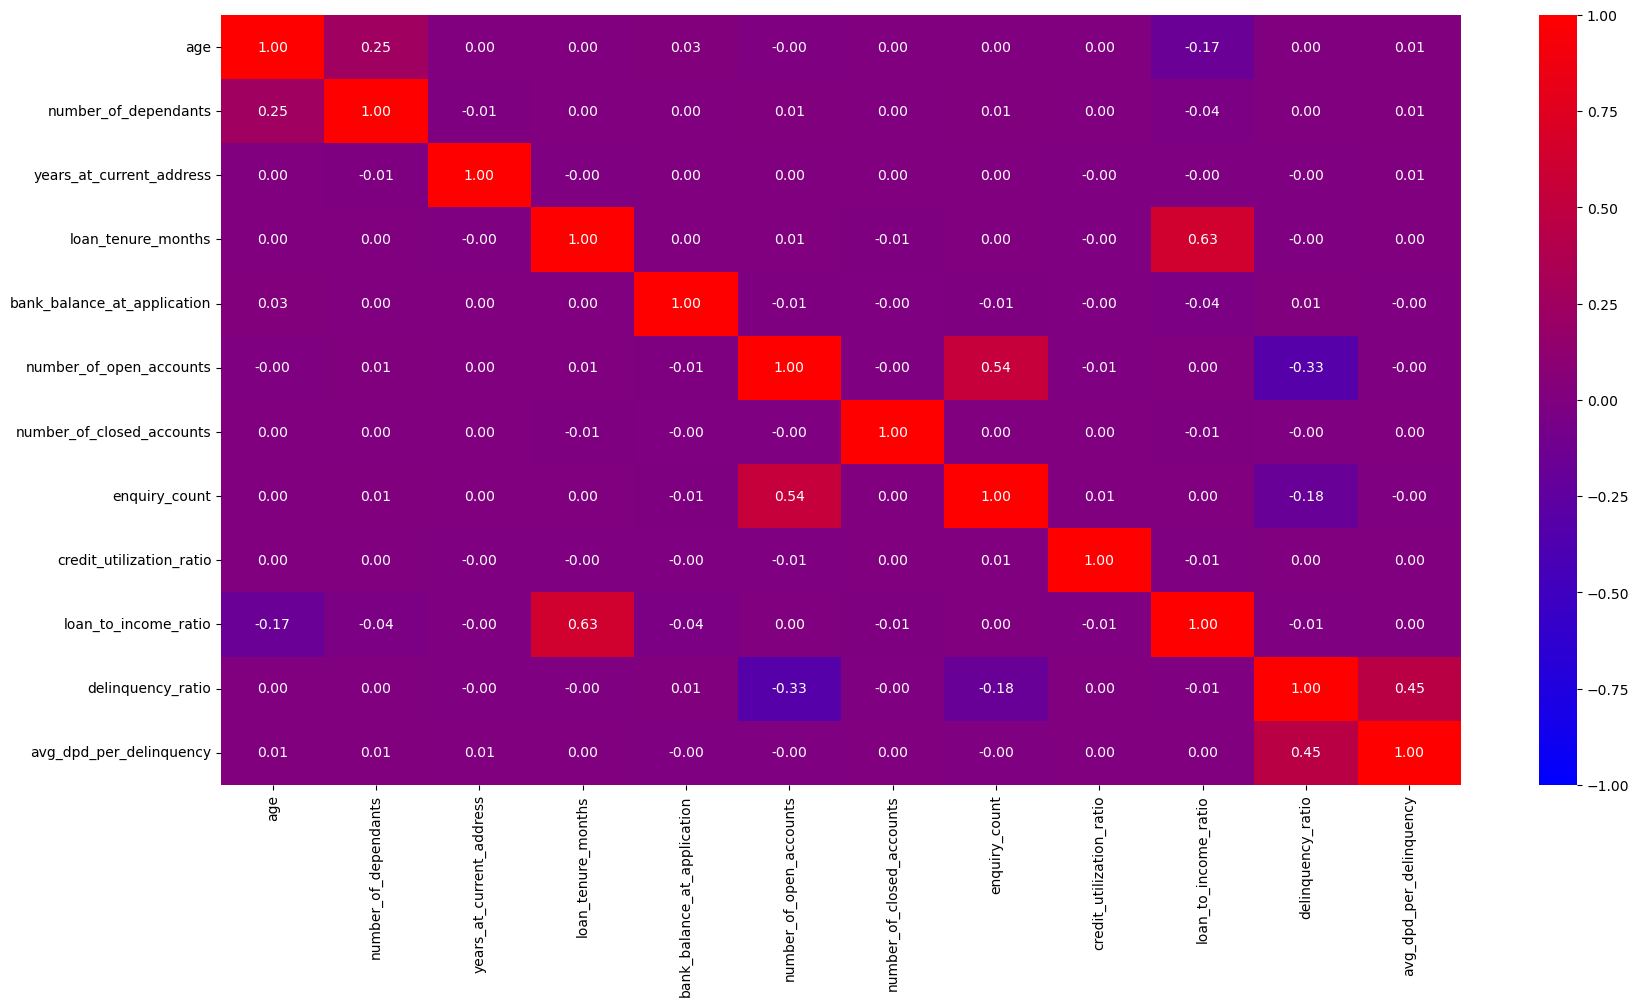

In [53]:
#printing the correlation chart
plt.figure(figsize=(20,10))
cols_for_corr= ["age","number_of_dependants","years_at_current_address","loan_tenure_months","bank_balance_at_application",
                "number_of_open_accounts","number_of_closed_accounts",
                "enquiry_count","credit_utilization_ratio","loan_to_income_ratio","delinquency_ratio",
                "avg_dpd_per_delinquency"]

cr = df_train_2[cols_for_corr].corr()
cm = sns.blend_palette(["blue", "red"], as_cmap=True)
sns.heatmap(cr,annot=True,fmt=".2f",vmin=-1,vmax=1,center=0,cmap=cm)
plt.show()

In [60]:
X_train_1.dtypes

age                            float64
gender                          object
marital_status                  object
employment_status               object
number_of_dependants           float64
residence_type                  object
years_at_current_address       float64
city                            object
state                           object
zipcode                         object
loan_purpose                    object
loan_type                       object
loan_tenure_months             float64
bank_balance_at_application    float64
number_of_open_accounts        float64
number_of_closed_accounts      float64
enquiry_count                  float64
credit_utilization_ratio       float64
loan_to_income_ratio           float64
delinquency_ratio              float64
avg_dpd_per_delinquency        float64
dtype: object

In [55]:
#changing the dtype of zipcode to object because it is a categorical column
df_train_2["default"] = df_train_2["zipcode"].astype("object")
X_train_1["zipcode"] = X_train_1["zipcode"].astype("object")
X_test["zipcode"] = X_test["zipcode"].astype("object")

In [56]:
def calculate_woe_iv(df, feature, target, epsilon=0.0001):
    grouped = df.groupby(feature)[target].agg(["count", "sum"])
    grouped = grouped.rename(columns={
        "count": "total",
        "sum": "good"
    })
    grouped["bad"] = grouped["total"] - grouped["good"]
    
    total_good = grouped["good"].sum()
    total_bad = grouped["bad"].sum()
    
    # add epsilon to avoid division by zero when total_good or total_bad is 0
    grouped["good_pct"] = grouped["good"] / (total_good + epsilon)
    grouped["bad_pct"] = grouped["bad"] / (total_bad + epsilon)
    
    # add epsilon to avoid log(0) or division by zero within each bin
    grouped["woe"] = np.log((grouped["good_pct"] + epsilon) / (grouped["bad_pct"] + epsilon))
    
    # safety net in case any inf/nan slip through
    grouped["woe"] = grouped["woe"].replace([np.inf, -np.inf], 0)
    grouped["woe"] = grouped["woe"].fillna(0)
    
    grouped["iv"] = grouped["woe"] * (grouped["good_pct"] - grouped["bad_pct"])
    grouped["iv"] = grouped["iv"].fillna(0)
    
    total_iv = grouped["iv"].sum()
    
    return grouped, total_iv

In [57]:
pd.cut(df_train_2["age"],bins=10,labels=False)

27434    5
13400    2
883      6
7303     4
45124    2
        ..
11284    2
44732    2
38158    3
860      4
15795    3
Name: age, Length: 37487, dtype: int64

In [66]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
total_ivs = []
for col in X_train_1.columns:
    if X_train_1[col].dtype == "object":
        _,total_iv = calculate_woe_iv(pd.concat([X_train_1,y_train],axis=1),col,"default")
        total_ivs.append(total_iv)
    else:
        X_binned = pd.cut(X_train_1[col],bins=10,labels=False)
        _,total_iv = calculate_woe_iv(pd.concat([X_train_1,y_train],axis=1),col,"default")
        total_ivs.append(total_iv)
    
iv_df = pd.DataFrame({
    "Column" : X_train_1.columns,
    "Total IV" : total_ivs
})    

In [68]:
iv_df = iv_df.sort_values(by = "Total IV",ascending=False)
iv_df

,Column,Total IV
17,credit_utilization_ratio,2.498
13,bank_balance_at_application,1.673
19,delinquency_ratio,1.161
18,loan_to_income_ratio,0.599
20,avg_dpd_per_delinquency,0.577
10,loan_purpose,0.394
12,loan_tenure_months,0.291
5,residence_type,0.259
11,loan_type,0.173
0,age,0.092


In [69]:
woe_iv_selected_features = [feature for feature, iv in zip(iv_df["Column"], iv_df["Total IV"]) if iv > 0.02]
woe_iv_selected_features

['credit_utilization_ratio',
 'bank_balance_at_application',
 'delinquency_ratio',
 'loan_to_income_ratio',
 'avg_dpd_per_delinquency',
 'loan_purpose',
 'loan_tenure_months',
 'residence_type',
 'loan_type',
 'age',
 'number_of_open_accounts']

In [70]:
X_train_reduced = X_train_1[woe_iv_selected_features]
X_test_reduced = X_test[woe_iv_selected_features]

In [71]:
X_train_reduced.head()

,credit_utilization_ratio,bank_balance_at_application,delinquency_ratio,loan_to_income_ratio,avg_dpd_per_delinquency,loan_purpose,loan_tenure_months,residence_type,loan_type,age,number_of_open_accounts
27434,0.596,0.070,0.067,0.609,0.550,Home,0.340,Owned,Secured,0.519,1.000
13400,0.929,0.119,0.034,0.183,0.425,Auto,0.509,Owned,Secured,0.212,0.667
883,0.838,0.096,0.169,0.084,0.557,Personal,0.245,Mortgage,Unsecured,0.615,0.333
7303,0.343,0.013,0.000,0.187,0.000,Auto,0.283,Owned,Secured,0.481,0.000
45124,0.192,0.006,0.097,0.361,0.467,Education,0.736,Owned,Secured,0.250,0.333


In [72]:
X_train_encoded = pd.get_dummies(X_train_reduced,drop_first=True)
X_test_encoded = pd.get_dummies(X_test_reduced,drop_first=True)

In [73]:
X_train_encoded.head()

,credit_utilization_ratio,bank_balance_at_application,delinquency_ratio,loan_to_income_ratio,avg_dpd_per_delinquency,loan_tenure_months,age,number_of_open_accounts,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,residence_type_Owned,residence_type_Rented,loan_type_Unsecured
27434,0.596,0.070,0.067,0.609,0.550,0.340,0.519,1.000,False,True,False,True,False,False
13400,0.929,0.119,0.034,0.183,0.425,0.509,0.212,0.667,False,False,False,True,False,False
883,0.838,0.096,0.169,0.084,0.557,0.245,0.615,0.333,False,False,True,False,False,True
7303,0.343,0.013,0.000,0.187,0.000,0.283,0.481,0.000,False,False,False,True,False,False
45124,0.192,0.006,0.097,0.361,0.467,0.736,0.250,0.333,True,False,False,True,False,False


In [74]:
X_train_encoded.shape

(37487, 14)

## Model Selection

Attempt 1 
1) Use Logistic Regression, Ramdom Forest and Xgboost
2) Find best parameters using Randomnized Search CV
3) Goal - High Recall > 90% (the model should correctly identify the default class), High F1 Score

In [75]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


lg_model = LogisticRegression(max_iter = 10000)
lg_model.fit(X_train_encoded,y_train)
y_pred = lg_model.predict(X_test_encoded)
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11390
           1       0.84      0.70      0.76      1108

    accuracy                           0.96     12498
   macro avg       0.90      0.84      0.87     12498
weighted avg       0.96      0.96      0.96     12498



In [76]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(X_train_encoded,y_train)
y_pred = rf_model.predict(X_test_encoded)
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11390
           1       0.84      0.69      0.76      1108

    accuracy                           0.96     12498
   macro avg       0.91      0.84      0.87     12498
weighted avg       0.96      0.96      0.96     12498



In [77]:
from xgboost import XGBClassifier

xg_model = RandomForestClassifier()
xg_model.fit(X_train_encoded,y_train)
y_pred = xg_model.predict(X_test_encoded)
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11390
           1       0.86      0.69      0.77      1108

    accuracy                           0.96     12498
   macro avg       0.91      0.84      0.87     12498
weighted avg       0.96      0.96      0.96     12498



From the above classification report, we can see that the tree based models do not significantly improve the f1 score and the recall of the default class as compared to Logistic Regression. Let's use Randomnized Search CV to tune the hyperparameters so as to improve the recall and f1 score

In [78]:
print(np.unique(y_train, return_counts=True))

(array([0, 1]), array([34298,  3189]))


In [79]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'C': np.logspace(-4, 4, 20),  # Logarithmically spaced values from 10^-4 to 10^4
    'solver': ['lbfgs', 'saga', 'liblinear', 'newton-cg']   # Algorithm to use in the optimization problem
}

# Create the Logistic Regression model
log_reg = LogisticRegression(max_iter=10000)  # Increased max_iter for convergence

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_dist,
    n_iter=50,  # Number of parameter settings that are sampled
    scoring='f1',
    cv=3,  # 5-fold cross-validation
    verbose=2,
    random_state=42,  # Set a random state for reproducibility
    n_jobs=-1  # Use all available cores
)

# Fit the RandomizedSearchCV to the training data
random_search.fit(X_train_encoded, y_train)

# Print the best parameters and best score
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Score: {random_search.best_score_}")

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test_encoded)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Parameters: {'solver': 'lbfgs', 'C': np.float64(78.47599703514607)}
Best Score: 0.7658021385593016
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11390
           1       0.83      0.71      0.77      1108

    accuracy                           0.96     12498
   macro avg       0.90      0.85      0.87     12498
weighted avg       0.96      0.96      0.96     12498



In [80]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report

# defining the parameter distribution to search over
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.5, 1],
    "min_child_weight": [1, 3, 5],
    "scale_pos_weight": [1, (y_train == 0).sum() / (y_train == 1).sum()]  # handles class imbalance
}

# base model
model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# randomized search
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# fitting on training data
random_search.fit(X_train_encoded, y_train)

# best parameters found
print("Best Parameters:", random_search.best_params_)
print("Best F1 Score (CV):", random_search.best_score_)

# using the best estimator to predict on test data
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test_encoded)

# classification report
report = classification_report(y_test, y_pred)
print(report)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'subsample': 0.8, 'scale_pos_weight': 1, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.8}
Best F1 Score (CV): 0.7827155083814452
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11390
           1       0.85      0.73      0.79      1108

    accuracy                           0.97     12498
   macro avg       0.91      0.86      0.89     12498
weighted avg       0.96      0.97      0.96     12498



Attempt 2
1) Using undersampling
2) Using Logistic Regression

In [81]:
from imblearn.under_sampling import RandomUnderSampler

sampler = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = sampler.fit_resample(X_train_encoded,y_train)
y_train_rus.value_counts()

default
0    3189
1    3189
Name: count, dtype: int64

In [82]:
model = LogisticRegression(max_iter = 10000)
model.fit(X_train_rus,y_train_rus)
y_pred = model.predict(X_test_encoded)
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.92      0.96     11390
           1       0.53      0.95      0.68      1108

    accuracy                           0.92     12498
   macro avg       0.76      0.94      0.82     12498
weighted avg       0.95      0.92      0.93     12498



In [83]:
model = XGBClassifier(**random_search.best_params_)
model.fit(X_train_rus, y_train_rus)

y_pred = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.93      0.96     11390
           1       0.59      0.96      0.73      1108

    accuracy                           0.94     12498
   macro avg       0.79      0.95      0.85     12498
weighted avg       0.96      0.94      0.94     12498



Attempt 3
1) Using SMOTE Tomek Oversampling
2) Using Logistic Regression
3) Parameter tunning using optuna

In [84]:
from imblearn.combine import SMOTETomek

sampler = SMOTETomek(random_state=42)
X_train_smt, y_train_smt = sampler.fit_resample(X_train_encoded,y_train)
y_train_smt.value_counts()

default
0    34243
1    34243
Name: count, dtype: int64

In [85]:
model = LogisticRegression(max_iter=10000)
model.fit(X_train_smt,y_train_smt)
y_pred_test = model.predict(X_test_encoded)
report = classification_report(y_test,y_pred_test)
print("="*50)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11390
           1       0.57      0.94      0.71      1108

    accuracy                           0.93     12498
   macro avg       0.78      0.93      0.83     12498
weighted avg       0.96      0.93      0.94     12498



In [87]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, make_scorer

In [88]:
# Define the objective function for Optuna
def objective(trial):
    param = {
        'C': trial.suggest_float('C', 1e-4, 1e4, log=True),  # Logarithmically spaced values
        'solver': trial.suggest_categorical('solver', ['lbfgs', 'liblinear', 'saga', 'newton-cg']),  # Solvers
        'tol': trial.suggest_float('tol', 1e-6, 1e-1, log=True),  # Logarithmically spaced values for tolerance
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced'])  # Class weights
    }

    model = LogisticRegression(**param, max_iter=10000)
    
    # Calculate the cross-validated f1_score
    f1_scorer = make_scorer(f1_score, average='macro')
    scores = cross_val_score(model, X_train_smt, y_train_smt, cv=3, scoring=f1_scorer, n_jobs=-1)
    
    return np.mean(scores)

study_logistic = optuna.create_study(direction='maximize')
study_logistic.optimize(objective, n_trials=50)

[I 2026-07-13 20:20:01,253] A new study created in memory with name: no-name-684503b4-66c7-4eee-995f-78a72aad49ca
[I 2026-07-13 20:20:01,404] Trial 0 finished with value: 0.9460769333440933 and parameters: {'C': 246.0164195440545, 'solver': 'liblinear', 'tol': 6.642929896232789e-05, 'class_weight': None}. Best is trial 0 with value: 0.9460769333440933.
[I 2026-07-13 20:20:01,525] Trial 1 finished with value: 0.9460766793902993 and parameters: {'C': 40.150613599613756, 'solver': 'liblinear', 'tol': 6.624046635239037e-05, 'class_weight': None}. Best is trial 0 with value: 0.9460769333440933.
[I 2026-07-13 20:20:01,591] Trial 2 finished with value: 0.9426602392409199 and parameters: {'C': 589.3993996228487, 'solver': 'newton-cg', 'tol': 0.006435554364024448, 'class_weight': None}. Best is trial 0 with value: 0.9460769333440933.
[I 2026-07-13 20:20:01,654] Trial 3 finished with value: 0.7854124416192733 and parameters: {'C': 0.00011381497059210084, 'solver': 'liblinear', 'tol': 0.002578523

In [89]:
print('Best trial:')
trial = study_logistic.best_trial
print('  F1-score: {}'.format(trial.value))
print('  Params: ')
for key, value in trial.params.items():
    print('    {}: {}'.format(key, value))
    
best_model_logistic = LogisticRegression(**study_logistic.best_params)
best_model_logistic.fit(X_train_smt, y_train_smt)

# Evaluate on the test set
y_pred = best_model_logistic.predict(X_test_encoded)

report = classification_report(y_test, y_pred)
print(report)

Best trial:
  F1-score: 0.9461206760681521
  Params: 
    C: 103.47317499194652
    solver: liblinear
    tol: 0.00011771058863831814
    class_weight: None
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11390
           1       0.57      0.94      0.71      1108

    accuracy                           0.93     12498
   macro avg       0.78      0.94      0.84     12498
weighted avg       0.96      0.93      0.94     12498



In [94]:
best_model = LogisticRegression(
    C = 103.47317499194652,
    solver = "liblinear",
    tol = 0.00011771058863831814,
    class_weight= None,
    max_iter = 10000
)
best_model.fit(X_train_smt,y_train_smt)
y_pred = best_model.predict(X_test_encoded)
report = classification_report(y_test,y_pred_test)
print("="*50)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11390
           1       0.57      0.94      0.71      1108

    accuracy                           0.93     12498
   macro avg       0.78      0.93      0.83     12498
weighted avg       0.96      0.93      0.94     12498



In [95]:
#printing roc_auc curve 

from sklearn.metrics import roc_curve, auc
probabilities = best_model.predict_proba(X_test_encoded)[:,1]
fpr,tpr,thresholds = roc_curve(y_test,probabilities)

In [96]:
auc_score = auc(fpr,tpr)
auc_score

np.float64(0.9830421580777362)

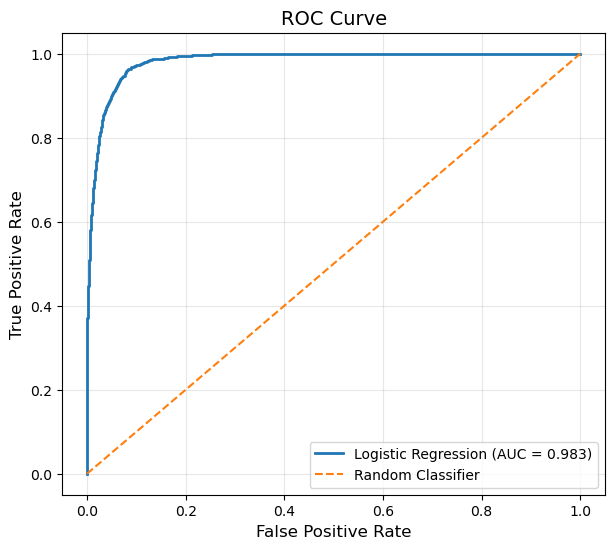

In [97]:
plt.figure(figsize=(7,6))

plt.plot(fpr, tpr,
         linewidth=2,
         label=f'Logistic Regression (AUC = {auc_score:.3f})')

plt.plot([0,1], [0,1],
         linestyle='--',
         linewidth=1.5,
         label='Random Classifier')

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve", fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

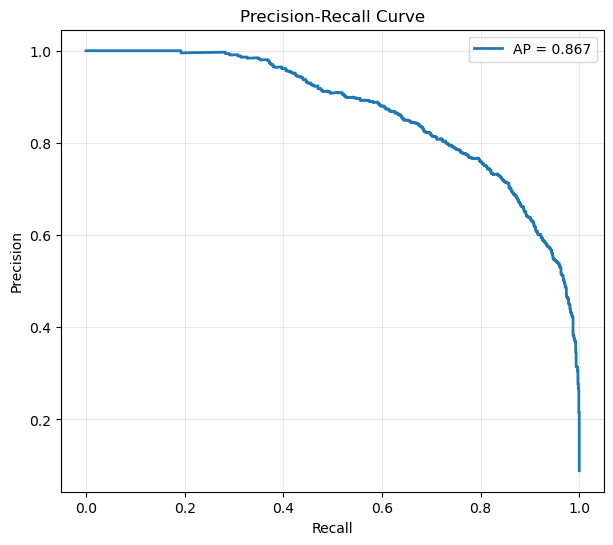

In [98]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, probabilities)
ap = average_precision_score(y_test, probabilities)

plt.figure(figsize=(7,6))

plt.plot(recall, precision,
         linewidth=2,
         label=f'AP = {ap:.3f}')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [99]:
#evaluation by KS_statistic

df_eval = pd.DataFrame({
    "Default Truth" : y_test,
    "Default Probability" : probabilities
})
df_eval = df_eval.sort_values(["Default Probability"],ascending=False)
df_eval.sample(3)

,Default Truth,Default Probability
42185,0,0.000
45882,0,0.209
23012,0,0.002


In [100]:
df_eval["Decile"] = pd.qcut(df_eval["Default Probability"],q=10,labels=False,duplicates="drop")
df_eval.sample(3)

,Default Truth,Default Probability,Decile
26218,0,0.000,2
10901,0,0.000,1
16750,1,0.976,9


In [101]:
df_eval_grouped = df_eval.groupby("Decile").apply(lambda x: pd.Series({
    "Min Probability" : x["Default Probability"].min(),
    "Max Probability" : x["Default Probability"].max(),
    "Events" : x["Default Truth"].sum(),
    "Non Events" : x["Default Truth"].count() - x["Default Truth"].sum()
}))
df_eval_grouped.reset_index(inplace=True)
df_eval_grouped

/var/folders/1r/nkv2ys25697drcm87zscd8vw0000gn/T/ipykernel_6389/2611782391.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_eval_grouped = df_eval.groupby("Decile").apply(lambda x: pd.Series({


,Decile,Min Probability,Max Probability,Events,Non Events
0,0,0.000,0.000,0.000,1250.000
1,1,0.000,0.000,0.000,1250.000
2,2,0.000,0.000,0.000,1250.000
3,3,0.000,0.000,0.000,1249.000
4,4,0.000,0.001,0.000,1250.000
5,5,0.001,0.004,1.000,1249.000
6,6,0.004,0.029,2.000,1247.000
7,7,0.029,0.196,17.000,1233.000
8,8,0.196,0.823,174.000,1076.000
9,9,0.824,1.000,914.000,336.000


In [102]:
df_eval_grouped["Event Rate"] = df_eval_grouped["Events"]*100 / (df_eval_grouped["Events"] + df_eval_grouped["Non Events"])
df_eval_grouped["Non Event Rate"] = df_eval_grouped["Non Events"]*100 / (df_eval_grouped["Events"] + df_eval_grouped["Non Events"])
df_eval_grouped

,Decile,Min Probability,Max Probability,Events,Non Events,Event Rate,Non Event Rate
0,0,0.000,0.000,0.000,1250.000,0.000,100.000
1,1,0.000,0.000,0.000,1250.000,0.000,100.000
2,2,0.000,0.000,0.000,1250.000,0.000,100.000
3,3,0.000,0.000,0.000,1249.000,0.000,100.000
4,4,0.000,0.001,0.000,1250.000,0.000,100.000
5,5,0.001,0.004,1.000,1249.000,0.080,99.920
6,6,0.004,0.029,2.000,1247.000,0.160,99.840
7,7,0.029,0.196,17.000,1233.000,1.360,98.640
8,8,0.196,0.823,174.000,1076.000,13.920,86.080
9,9,0.824,1.000,914.000,336.000,73.120,26.880


In [103]:
df_eval_grouped = df_eval_grouped.sort_values(["Decile"],ascending=False).reset_index(drop=True)
df_eval_grouped

,Decile,Min Probability,Max Probability,Events,Non Events,Event Rate,Non Event Rate
0,9,0.824,1.000,914.000,336.000,73.120,26.880
1,8,0.196,0.823,174.000,1076.000,13.920,86.080
2,7,0.029,0.196,17.000,1233.000,1.360,98.640
3,6,0.004,0.029,2.000,1247.000,0.160,99.840
4,5,0.001,0.004,1.000,1249.000,0.080,99.920
5,4,0.000,0.001,0.000,1250.000,0.000,100.000
6,3,0.000,0.000,0.000,1249.000,0.000,100.000
7,2,0.000,0.000,0.000,1250.000,0.000,100.000
8,1,0.000,0.000,0.000,1250.000,0.000,100.000
9,0,0.000,0.000,0.000,1250.000,0.000,100.000


In [104]:
df_eval_grouped["Cum Events"] = df_eval_grouped["Events"].cumsum()
df_eval_grouped["Cum Non Events"] = df_eval_grouped["Non Events"].cumsum()
df_eval_grouped

,Decile,Min Probability,Max Probability,Events,Non Events,Event Rate,Non Event Rate,Cum Events,Cum Non Events
0,9,0.824,1.000,914.000,336.000,73.120,26.880,914.000,336.000
1,8,0.196,0.823,174.000,1076.000,13.920,86.080,1088.000,1412.000
2,7,0.029,0.196,17.000,1233.000,1.360,98.640,1105.000,2645.000
3,6,0.004,0.029,2.000,1247.000,0.160,99.840,1107.000,3892.000
4,5,0.001,0.004,1.000,1249.000,0.080,99.920,1108.000,5141.000
5,4,0.000,0.001,0.000,1250.000,0.000,100.000,1108.000,6391.000
6,3,0.000,0.000,0.000,1249.000,0.000,100.000,1108.000,7640.000
7,2,0.000,0.000,0.000,1250.000,0.000,100.000,1108.000,8890.000
8,1,0.000,0.000,0.000,1250.000,0.000,100.000,1108.000,10140.000
9,0,0.000,0.000,0.000,1250.000,0.000,100.000,1108.000,11390.000


In [105]:
df_eval_grouped["Cum Event Rate"] = df_eval_grouped["Cum Events"]*100/df_eval_grouped["Events"].sum()
df_eval_grouped["Cum Non Event Rate"] = df_eval_grouped["Cum Non Events"]*100/df_eval_grouped["Non Events"].sum()
df_eval_grouped

,Decile,Min Probability,Max Probability,Events,Non Events,Event Rate,Non Event Rate,Cum Events,Cum Non Events,Cum Event Rate,Cum Non Event Rate
0,9,0.824,1.000,914.000,336.000,73.120,26.880,914.000,336.000,82.491,2.950
1,8,0.196,0.823,174.000,1076.000,13.920,86.080,1088.000,1412.000,98.195,12.397
2,7,0.029,0.196,17.000,1233.000,1.360,98.640,1105.000,2645.000,99.729,23.222
3,6,0.004,0.029,2.000,1247.000,0.160,99.840,1107.000,3892.000,99.910,34.170
4,5,0.001,0.004,1.000,1249.000,0.080,99.920,1108.000,5141.000,100.000,45.136
5,4,0.000,0.001,0.000,1250.000,0.000,100.000,1108.000,6391.000,100.000,56.111
6,3,0.000,0.000,0.000,1249.000,0.000,100.000,1108.000,7640.000,100.000,67.076
7,2,0.000,0.000,0.000,1250.000,0.000,100.000,1108.000,8890.000,100.000,78.051
8,1,0.000,0.000,0.000,1250.000,0.000,100.000,1108.000,10140.000,100.000,89.025
9,0,0.000,0.000,0.000,1250.000,0.000,100.000,1108.000,11390.000,100.000,100.000


In [106]:
df_eval_grouped["KS"] = abs(df_eval_grouped["Cum Event Rate"] - df_eval_grouped["Cum Non Event Rate"])
df_eval_grouped

,Decile,Min Probability,Max Probability,Events,Non Events,Event Rate,Non Event Rate,Cum Events,Cum Non Events,Cum Event Rate,Cum Non Event Rate,KS
0,9,0.824,1.000,914.000,336.000,73.120,26.880,914.000,336.000,82.491,2.950,79.541
1,8,0.196,0.823,174.000,1076.000,13.920,86.080,1088.000,1412.000,98.195,12.397,85.798
2,7,0.029,0.196,17.000,1233.000,1.360,98.640,1105.000,2645.000,99.729,23.222,76.507
3,6,0.004,0.029,2.000,1247.000,0.160,99.840,1107.000,3892.000,99.910,34.170,65.739
4,5,0.001,0.004,1.000,1249.000,0.080,99.920,1108.000,5141.000,100.000,45.136,54.864
5,4,0.000,0.001,0.000,1250.000,0.000,100.000,1108.000,6391.000,100.000,56.111,43.889
6,3,0.000,0.000,0.000,1249.000,0.000,100.000,1108.000,7640.000,100.000,67.076,32.924
7,2,0.000,0.000,0.000,1250.000,0.000,100.000,1108.000,8890.000,100.000,78.051,21.949
8,1,0.000,0.000,0.000,1250.000,0.000,100.000,1108.000,10140.000,100.000,89.025,10.975
9,0,0.000,0.000,0.000,1250.000,0.000,100.000,1108.000,11390.000,100.000,100.000,0.000


In [107]:
#Gini Coefficient 
gini_coeff = 2 * auc_score - 1
gini_coeff

np.float64(0.9660843161554724)

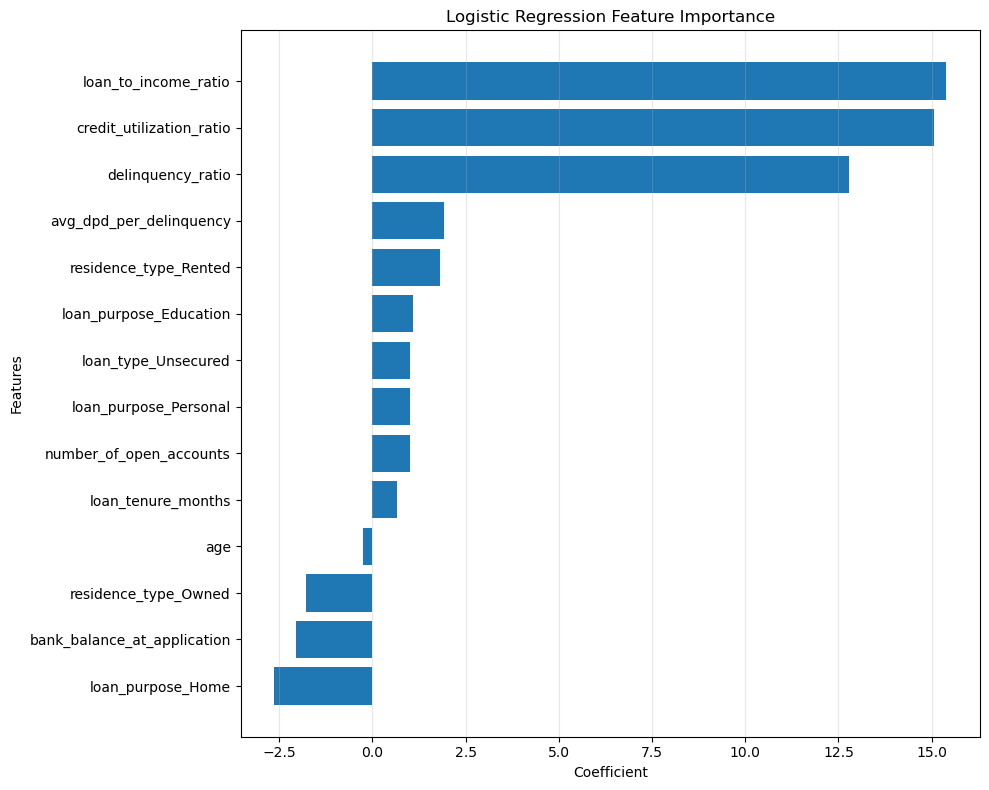

In [108]:
## Feature Importance Chart

feature_importance = pd.DataFrame({
    "Feature": X_train_encoded.columns,
    "Importance": model.coef_[0]
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=True
)

# Plot
plt.figure(figsize=(10,8))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Coefficient")
plt.ylabel("Features")
plt.title("Logistic Regression Feature Importance")
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [109]:
#Model Export

from joblib import dump
model_data = {
    "model" : model,
    "features" : X_train_encoded.columns,
    "scaler" : scaler,
    "cols_to_scale" : cols_to_scale
}
dump(model_data,"app/Artifacts/model_data.joblib")

['app/Artifacts/model_data.joblib']

In [110]:
model.coef_, model.intercept_

(array([[15.05088337, -2.04697752, 12.7900599 , 15.39412003,  1.91492867,
          0.66285108, -0.24627452,  0.9952065 ,  1.0855421 , -2.63228001,
          1.00484136, -1.7934866 ,  1.82293848,  1.00484136]]),
 array([-19.13296355]))

In [111]:
X_train_encoded.columns

Index(['credit_utilization_ratio', 'bank_balance_at_application',
       'delinquency_ratio', 'loan_to_income_ratio', 'avg_dpd_per_delinquency',
       'loan_tenure_months', 'age', 'number_of_open_accounts',
       'loan_purpose_Education', 'loan_purpose_Home', 'loan_purpose_Personal',
       'residence_type_Owned', 'residence_type_Rented', 'loan_type_Unsecured'],
      dtype='object')

In [112]:
cols_to_scale

['age',
 'number_of_dependants',
 'years_at_current_address',
 'sanction_amount',
 'processing_fee',
 'gst',
 'net_disbursement',
 'loan_tenure_months',
 'principal_outstanding',
 'bank_balance_at_application',
 'number_of_open_accounts',
 'number_of_closed_accounts',
 'enquiry_count',
 'credit_utilization_ratio',
 'loan_to_income_ratio',
 'delinquency_ratio',
 'avg_dpd_per_delinquency']

In [113]:
X_test_encoded

,credit_utilization_ratio,bank_balance_at_application,delinquency_ratio,loan_to_income_ratio,avg_dpd_per_delinquency,loan_tenure_months,age,number_of_open_accounts,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,residence_type_Owned,residence_type_Rented,loan_type_Unsecured
33553,0.121,0.226,0.043,0.258,0.900,0.528,0.346,0.333,True,False,False,True,False,False
9427,0.859,0.101,0.000,0.689,0.000,0.623,0.288,1.000,False,True,False,True,False,False
199,0.727,0.040,0.000,0.635,0.000,0.623,0.192,1.000,False,True,False,True,False,False
12447,0.909,0.042,0.000,0.187,0.000,0.189,0.192,0.667,False,False,False,False,True,False
39489,0.535,0.061,0.132,0.169,0.525,0.377,0.654,1.000,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9771,0.192,0.018,0.167,0.119,0.686,0.038,0.462,0.333,False,False,True,True,False,True
34737,0.172,0.133,0.000,0.218,0.000,0.358,0.423,0.667,False,False,False,False,False,False
30390,0.273,0.075,0.000,0.073,0.000,0.245,0.327,0.000,False,False,True,False,False,True
6797,0.162,0.048,0.054,0.094,0.640,0.283,0.712,0.667,False,False,True,True,False,True
